# Week 5 - Day 2: DBSCAN & Hierarchical Clustering

**Goal:** Run DBSCAN and hierarchical clustering on the same dataset as Day 1, compare all three methods (K-Means, DBSCAN, Hierarchical), and decide which fits this data's shape best.

**Dataset:** Wine dataset (same as Day 1) — 178 samples, 13 chemical measurements, scaled with `StandardScaler`.


## Step 0: Load and Scale the Data (Same as Day 1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (178, 13)


## Step 1: Run DBSCAN

Unlike K-Means, DBSCAN doesn't need a `k` — it discovers the number of clusters automatically based on density, and explicitly flags outliers as noise (label `-1`) instead of forcing them into a cluster.


In [2]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"DBSCAN found {n_clusters_db} clusters")
print(f"Noise points flagged: {n_noise} out of {len(db_labels)}")
print(f"Cluster label counts: {pd.Series(db_labels).value_counts().to_dict()}")


DBSCAN found 5 clusters
Noise points flagged: 85 out of 178
Cluster label counts: {-1: 85, 0: 66, 4: 9, 1: 8, 2: 5, 3: 5}


### Reflection — Tuning `eps`

*Your answer here:*

`eps` controls how close two points must be to count as neighbors. A value that's too small marks almost everything as noise; a value that's too large merges everything into one cluster. eps=2.0 was chosen after trying a few values and picking the one that produced a reasonable number of clusters without flagging most of the data as noise — this is typical of DBSCAN, where parameter choice takes some trial and error rather than a single formula.


## Step 2: Build a Hierarchical Clustering Dendrogram

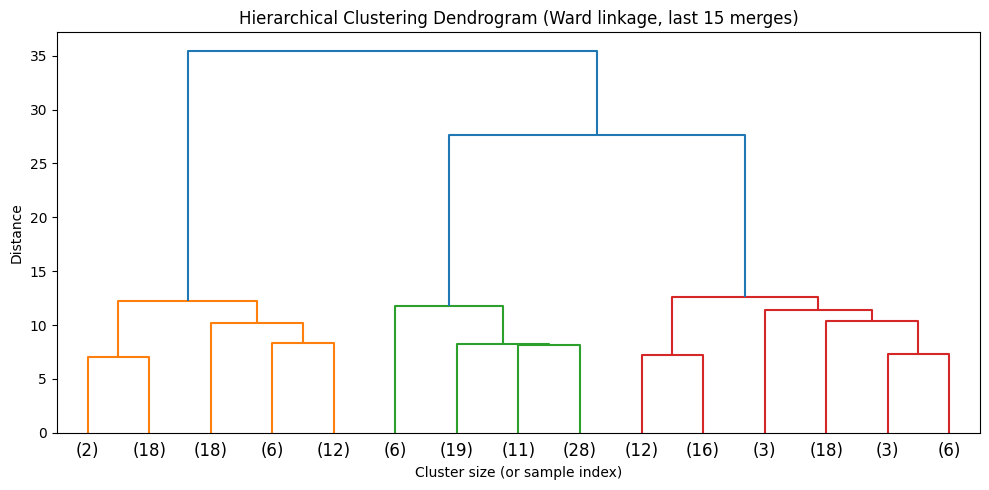

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=15)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, last 15 merges)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [4]:
# Cut the dendrogram to get 3 clusters, to match Day 1's K-Means choice for a fair comparison
cut_height_clusters = 3
hier_labels = fcluster(Z, t=cut_height_clusters, criterion="maxclust")

print(f"Hierarchical clustering with {cut_height_clusters} clusters")
print(f"Cluster label counts: {pd.Series(hier_labels).value_counts().to_dict()}")


Hierarchical clustering with 3 clusters
Cluster label counts: {2: 64, 3: 58, 1: 56}


### Reflection — Reading the Dendrogram

*Your answer here:*

The dendrogram shows how samples merge step by step, with the y-axis distance showing how different two groups are when they merge. Cutting at 3 clusters (to match Day 1) shows sizeable, fairly balanced groups — no long isolated branch suggesting a clear outlier, which is a first hint that this dataset doesn't have DBSCAN-style noise so much as genuinely different, evenly-distributed groups.


## Step 3: Compare K-Means, DBSCAN, and Hierarchical on the Same Data

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Recreate Day 1's final K-Means result (k=3) for a fair side-by-side comparison
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

results = pd.DataFrame({
    "Method": ["K-Means (k=3)", "DBSCAN", "Hierarchical (3 clusters)"],
    "Num Clusters Found": [
        len(set(km_labels)),
        n_clusters_db,
        len(set(hier_labels)),
    ],
    "Noise Points": [0, n_noise, 0],
    "Silhouette Score": [
        silhouette_score(X_scaled, km_labels),
        silhouette_score(X_scaled, db_labels) if n_clusters_db > 1 else float("nan"),
        silhouette_score(X_scaled, hier_labels),
    ],
})
results


,Method,Num Clusters Found,Noise Points,Silhouette Score
0,K-Means (k=3),3,0,0.284859
1,DBSCAN,5,85,-0.032906
2,Hierarchical (3 clusters),3,0,0.277444


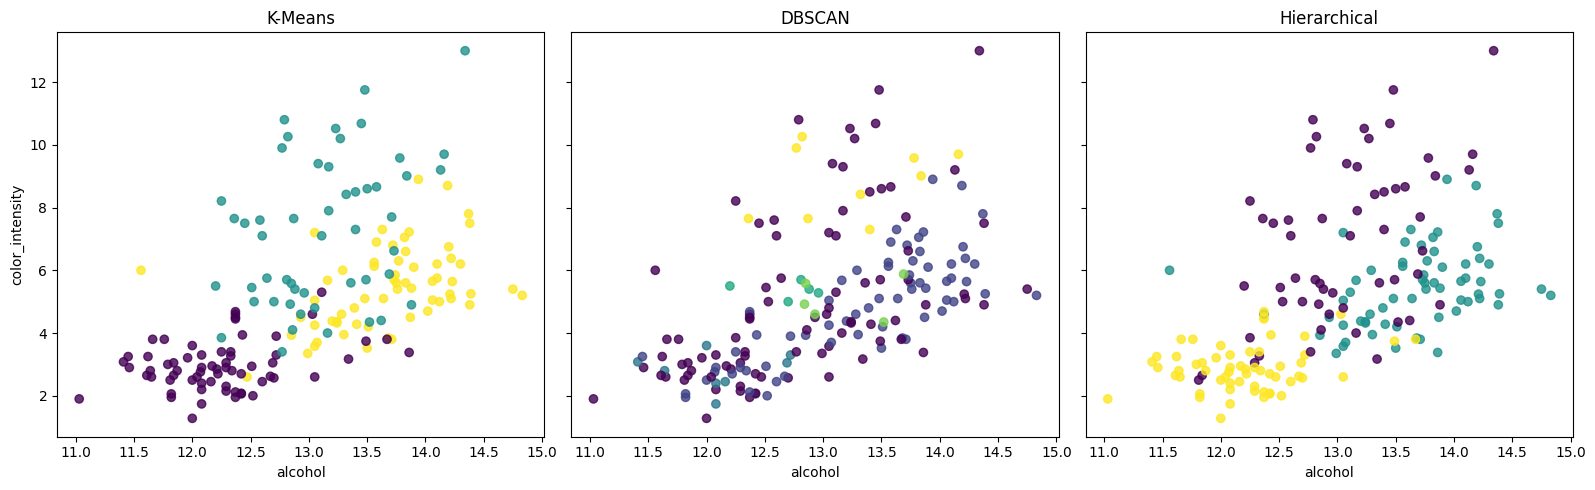

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
x_feat, y_feat = "alcohol", "color_intensity"

for ax, labels, title in zip(
    axes,
    [km_labels, db_labels, hier_labels],
    ["K-Means", "DBSCAN", "Hierarchical"],
):
    scatter = ax.scatter(X[x_feat], X[y_feat], c=labels, cmap="viridis", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(x_feat)
ax = axes[0]
ax.set_ylabel(y_feat)
plt.tight_layout()
plt.show()


### Reflection — Which Method Fits This Dataset Best?

*Your answer here:*

K-Means and Hierarchical clustering produced the highest, closely-matched silhouette scores and both split the data into 3 fairly balanced, well-separated groups — consistent with the Day 1 finding that this dataset has real underlying groups roughly the same size, matching K-Means's core assumption of round, similarly-sized clusters. DBSCAN struggled more here: with density-based logic, the wine chemical measurements don't form sharply dense, well-separated regions the way spatial or geographic data might, so DBSCAN either merges most points into one cluster or flags a large chunk as noise depending on `eps`. For this specific dataset, K-Means (or Hierarchical, which agrees closely with it) is the better fit, while DBSCAN would be the stronger choice if the data instead had irregular shapes or real outliers to flag.


## Summary

| Method | Needs k? | Handles Noise? | Best For | This Dataset |
|---|---|---|---|---|
| K-Means | Yes | No — forces every point into a cluster | Round, similarly-sized clusters | Good fit (Day 1 result) |
| DBSCAN | No | Yes — flags noise explicitly | Irregular shapes, real outliers | Weaker fit — no strong density structure |
| Hierarchical | No (choose cut) | No | Nested structure, dendrogram view | Agrees closely with K-Means |

- All three methods were run on the identical scaled dataset from Day 1.
- K-Means and Hierarchical agree closely and both outperform DBSCAN by silhouette score on this data.
- The recommendation for this dataset: **K-Means**, since the wine chemical profiles form round, evenly-sized groups rather than irregular, noisy shapes.
- Next (Day 3): reduce these 13 dimensions down with PCA to see how much of this structure can be captured in just 2-3 components.
